# Sales Exploratory Data Analysis
### Made By - [`Pratyush Puri`](https://www.linkedin.com/in/pratyushpuri)

<br>

## Data Loading and Initial Exploration

In [61]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
w.filterwarnings('ignore')
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [2]:
# data loading
cust = 'https://raw.githubusercontent.com/PratyushPuri/ProjectDatasets/main/new_sale/customers.csv'
geo = 'https://raw.githubusercontent.com/PratyushPuri/ProjectDatasets/main/new_sale/geolocation.csv'
oi = 'https://raw.githubusercontent.com/PratyushPuri/ProjectDatasets/main/new_sale/order_items.csv'
pay = 'https://raw.githubusercontent.com/PratyushPuri/ProjectDatasets/main/new_sale/payments.csv'
prod = 'https://raw.githubusercontent.com/PratyushPuri/ProjectDatasets/main/new_sale/products.csv'
sell = 'https://raw.githubusercontent.com/PratyushPuri/ProjectDatasets/main/new_sale/sellers.csv'
ord = 'https://raw.githubusercontent.com/PratyushPuri/ProjectDatasets/main/new_sale/orders.csv'

customers = pd.read_csv(cust)
geolocation = pd.read_csv(geo)
order_items = pd.read_csv(oi)
payments = pd.read_csv(pay)
products = pd.read_csv(prod)
sellers = pd.read_csv(sell)
orders = pd.read_csv(ord)

sellers.sample()


,seller_id,seller_zip_code_prefix,seller_city,seller_state
1461,3d2400ac620cffa23ac81bd192f7f555,9810,sao bernardo do campo,SP


In [3]:
orders.sample()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
56391,31b0ad9590cbb7cce97820802ad69c6b,9d16c341ca16f398e709ae9ce1203049,delivered,2018-08-15 17:35:07,2018-08-15 17:45:26,2018-08-24 12:47:00,2018-08-27 19:38:55,2018-08-31 0:00:00


In [4]:
customers.sample()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
9422,e53b534236436f97ebaf56e1f3929c46,72b6baa5f61ff8943a39d2d59c11414b,19820,taruma,SP


In [5]:
geolocation.sample()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
565544,31550,-19.840908,-43.982647,belo horizonte,MG


In [6]:
order_items.sample()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
22974,3473b2ac470644fed5ff35254ec7a759,1,86b8032cbb666ec9ca1f2aa4d4cace06,dee656f0f566ed1aa85bd137c943f08f,2017-12-28 2:12:38,67.9,34.28


In [7]:
payments.sample()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
84543,2ccca1fe20c84ea4cb95b191e260cf16,1,UPI,1,31.38


In [8]:
products.sample()

,product_id,product category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
18022,5568499d3c902609fbaa24d6639ef909,telephony,58.0,540.0,3.0,350.0,17.0,4.0,12.0


In [9]:
orders.columns.to_list()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [10]:
customers.columns.to_list()

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [11]:
geolocation.columns.to_list()

['geolocation_zip_code_prefix',
 'geolocation_lat',
 'geolocation_lng',
 'geolocation_city',
 'geolocation_state']

In [12]:
order_items.columns.to_list()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [13]:
payments.columns.to_list()

['order_id',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value']

In [14]:
products.columns.to_list()

['product_id',
 'product category',
 'product_name_length',
 'product_description_length',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [15]:
sellers.columns.to_list()

['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

In [16]:
'''
MERGING ALL INTO ONE BIG DATAFRAME 'df' (except geolocation)
'''


#Merge order_items + products (on product_id)
df = order_items.merge(products, on='product_id', how='left')

# Add sellers (on seller_id)
df = df.merge(sellers, on='seller_id', how='left')

# Add orders
df = df.merge(orders, on='order_id', how='left')

#Add customers
df = df.merge(customers, on='customer_id', how='left')

# Aggregating payments first, then merging
payments_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_type=('payment_type', 'first')
).reset_index()
df = df.merge(payments_agg, on='order_id', how='left')


In [17]:
df.sample()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_type
47293,6b7c51889439d1226b105ac94db9688d,1,19c91ef95d509ea33eda93495c4d3481,06a2c3af7b3aee5d69171b0e14f0ee87,2018-07-15 21:50:11,122.99,30.11,HEALTH BEAUTY,50.0,1257.0,1.0,700.0,25.0,12.0,19.0,65072,sao luis,MA,80d559f43415392b923172d3a7137c60,delivered,2018-07-08 21:38:25,2018-07-08 21:50:11,2018-07-13 13:38:00,2018-07-23 21:32:23,2018-07-31 0:00:00,d94dabf89b0f9242bfbbfd72451d8ac9,2565,sao paulo,SP,153.1,credit_card


In [18]:
df.columns.to_list()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product category',
 'product_name_length',
 'product_description_length',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'total_payment',
 'payment_type']

In [19]:
df.shape

(112650, 31)

In [20]:
df.dtypes

,0
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,object
price,float64
freight_value,float64
product category,object
product_name_length,float64
product_description_length,float64


In [21]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,112650,98666,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_item_id,112650.0,NaN,NaN,NaN,1.197834,0.705124,1.0,1.0,1.0,1.0,21.0
product_id,112650,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_id,112650,3095,6560211a19b47992c3666cc44a7e94c0,2033,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_limit_date,112650,93318,2017-07-21 18:25:23,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,112650.0,NaN,NaN,NaN,120.653739,183.633928,0.85,39.9,74.99,134.9,6735.0
freight_value,112650.0,NaN,NaN,NaN,19.99032,15.806405,0.0,13.08,16.26,21.15,409.68
product category,111047,73,bed table bath,11115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name_length,111047.0,NaN,NaN,NaN,48.775978,10.025581,5.0,42.0,52.0,57.0,76.0
product_description_length,111047.0,NaN,NaN,NaN,787.867029,652.135608,4.0,348.0,603.0,987.0,3992.0


<Axes: ylabel='Density'>

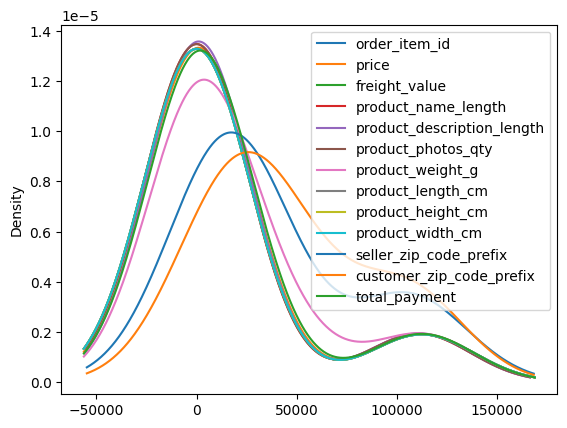

In [22]:
df.describe(include='all').plot(kind='kde')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   product category               111047 non-null  object 
 8   product_name_length            111047 non-null  float64
 9   product_description_length     111047 non-null  float64
 10  product_photos_qty             111047 non-null  float64
 11  product_weight_g               112632 non-null  float64
 12  product_length_cm             

In [24]:
df.nunique()

,0
order_id,98666
order_item_id,21
product_id,32951
seller_id,3095
shipping_limit_date,93318
price,5968
freight_value,6999
product category,73
product_name_length,66
product_description_length,2960


## Data Cleaning

In [25]:
# checking for duplicates

df.duplicated().sum()

np.int64(0)

changing wrong column dtypes to right ones ,
`shipping_limit_date`,  `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` and `order_estimated_delivery_date` have wrong dtypes that is `object` so changing them back to `datetime`

In [26]:
date_cols = ['shipping_limit_date', 'order_purchase_timestamp', 'order_approved_at','order_delivered_carrier_date',
             'order_delivered_customer_date','order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f'{col} has now dtype of {df[col].dtype}')


shipping_limit_date has now dtype of datetime64[ns]
order_purchase_timestamp has now dtype of datetime64[ns]
order_approved_at has now dtype of datetime64[ns]
order_delivered_carrier_date has now dtype of datetime64[ns]
order_delivered_customer_date has now dtype of datetime64[ns]
order_estimated_delivery_date has now dtype of datetime64[ns]


In [27]:
for col in df.columns:
  if df[col].isna().sum() > 0:
    print(f'''"{col}" of dtype "{df[col].dtype}" has {df[col].isna().sum()} missing values with {round(df[col].isna().sum()/df.shape[0]*100,2)}%''')

"product category" of dtype "object" has 1603 missing values with 1.42%
"product_name_length" of dtype "float64" has 1603 missing values with 1.42%
"product_description_length" of dtype "float64" has 1603 missing values with 1.42%
"product_photos_qty" of dtype "float64" has 1603 missing values with 1.42%
"product_weight_g" of dtype "float64" has 18 missing values with 0.02%
"product_length_cm" of dtype "float64" has 18 missing values with 0.02%
"product_height_cm" of dtype "float64" has 18 missing values with 0.02%
"product_width_cm" of dtype "float64" has 18 missing values with 0.02%
"order_approved_at" of dtype "datetime64[ns]" has 15 missing values with 0.01%
"order_delivered_carrier_date" of dtype "datetime64[ns]" has 1194 missing values with 1.06%
"order_delivered_customer_date" of dtype "datetime64[ns]" has 2454 missing values with 2.18%
"total_payment" of dtype "float64" has 3 missing values with 0.0%
"payment_type" of dtype "object" has 3 missing values with 0.0%


In [28]:
## Dropping null rows with 0.05% null values
list5 = ['product_weight_g', 'product_length_cm', 'product_height_cm',
         'product_width_cm', 'order_approved_at', 'total_payment', 'payment_type']

df.dropna(subset=list5, inplace=True)

for col in list5:
    print(f"{col}: {df[col].isna().sum()} nulls remaining")

product_weight_g: 0 nulls remaining
product_length_cm: 0 nulls remaining
product_height_cm: 0 nulls remaining
product_width_cm: 0 nulls remaining
order_approved_at: 0 nulls remaining
total_payment: 0 nulls remaining
payment_type: 0 nulls remaining


In [29]:
# filling of rest null values

df['product category'] = df['product category'].fillna('Unknown')

num_cols = ['product_name_length', 'product_description_length', 'product_photos_qty']

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

date_cols = ['order_delivered_carrier_date', 'order_delivered_customer_date']

for col in date_cols:
    mean_ts = pd.to_datetime(df[col].dropna().astype('int64').median())
    df[col] = df[col].fillna(mean_ts)


In [30]:
for col in df.columns:
  if df[col].isna().sum() > 0:
    print(f'''"{col}" of dtype "{df[col].dtype}" has {df[col].isna().sum()} missing values with {round(df[col].isna().sum()/df.shape[0]*100,2)}%''')

No NULL values left

## Data Cleaning (Geolocation)

In [31]:
geolocation.sample()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
65186,3735,-23.508821,-46.521394,sao paulo,SP


In [32]:
# checking information

geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [33]:
# describing dataset

geolocation.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,1000163.0,NaN,NaN,NaN,36574.166466,30549.33571,1001.0,11075.0,26530.0,63504.0,99990.0
geolocation_lat,1000163.0,NaN,NaN,NaN,-21.176153,5.715866,-36.605374,-23.603546,-22.919377,-19.97962,45.065933
geolocation_lng,1000163.0,NaN,NaN,NaN,-46.390541,4.269748,-101.466766,-48.573172,-46.637879,-43.767709,121.105394
geolocation_city,1000163,8011,sao paulo,135800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geolocation_state,1000163,27,SP,404268,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
#checking for unique values (if any)
geolocation.nunique()

,0
geolocation_zip_code_prefix,19015
geolocation_lat,717360
geolocation_lng,717613
geolocation_city,8011
geolocation_state,27


In [35]:
#checking for duplicates
geolocation.duplicated().sum()

np.int64(261831)

In [36]:
#dropping duplicates
geolocation.drop_duplicates(inplace=True)
geolocation.duplicated().sum()

np.int64(0)

In [38]:
# verifying shape
geolocation.shape

(738332, 5)

In [39]:
# checking for null values if any
geolocation.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


## Exploratory Data Analysis

### List all unique cities where customers are located

In [41]:
# Extract unique customer cities
unique_cities = df['customer_city'].dropna().unique()

print(f"Total number of unique cities: {len(unique_cities)}")
print(f"Sample of cities: {unique_cities[:10]}")

Total number of unique cities: 4109
Sample of cities: ['campos dos goytacazes' 'santa fe do sul' 'para de minas' 'atibaia'
 'varzea paulista' 'uberaba' 'guararapes' 'praia grande' 'santos'
 'jandira']


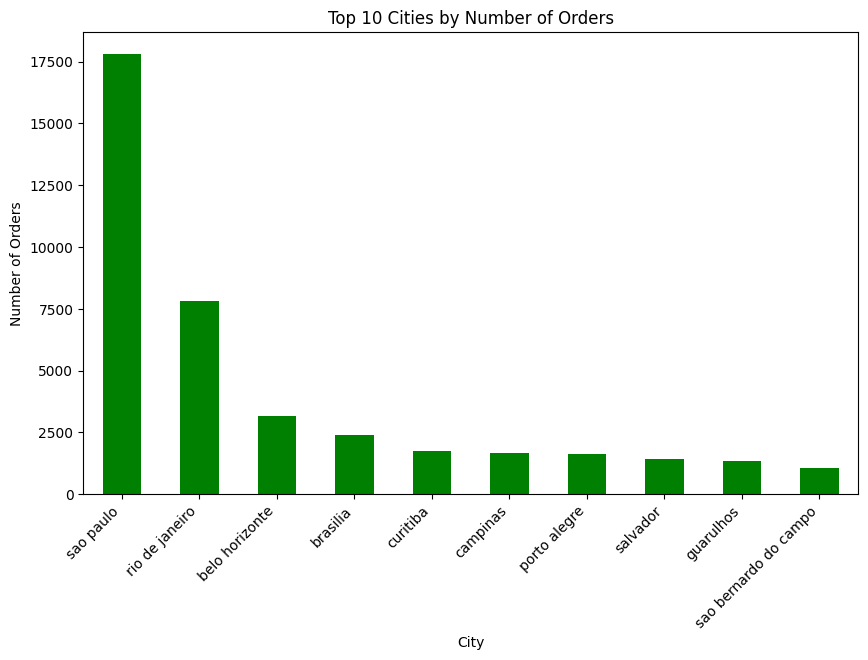

In [47]:
#  Top 10 Cities

plt.figure(figsize=(10, 6))
df['customer_city'].value_counts().head(10).plot(kind='bar', color='green')
plt.title('Top 10 Cities by Number of Orders')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.show()

### Count the number of orders placed in 2017

In [49]:
# Filtering for 2017 and count unique order IDs
orders_2017 = df[df['order_purchase_timestamp'].dt.year == 2017]['order_id'].nunique()
print(f"Total unique orders placed in 2017: {orders_2017}")

Total unique orders placed in 2017: 44549


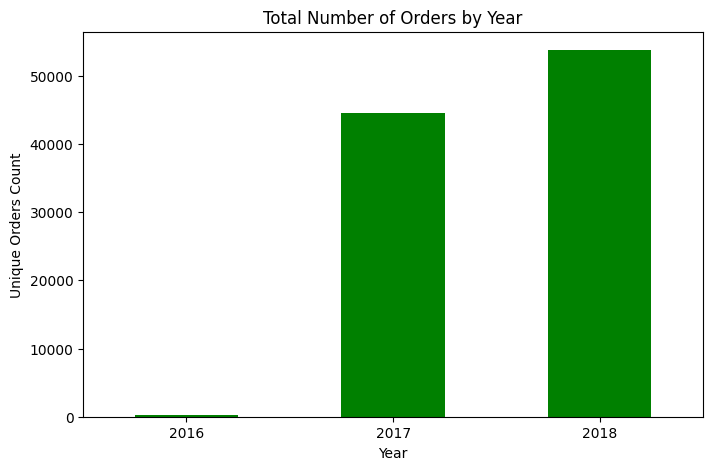

In [53]:
# orders by year
plt.figure(figsize=(8, 5))
df.groupby(df['order_purchase_timestamp'].dt.year)['order_id'].nunique().plot(kind='bar', color='green')
plt.title('Total Number of Orders by Year')
plt.xlabel('Year')
plt.ylabel('Unique Orders Count')
plt.xticks(rotation=0)
plt.show()

### Find the total sales per category

In [62]:
# Group by product category and sum the price column
sales_per_category = df.groupby('product category')['price'].sum().sort_values(ascending=False)

print("Total sales :")
print(sales_per_category.T)

Total sales for the top 5 categories:
product category
HEALTH BEAUTY                                       1258546.37
Watches present                                     1205005.68
bed table bath                                      1036854.69
sport leisure                                        987979.99
computer accessories                                 911954.32
Furniture Decoration                                 729506.89
Cool Stuff                                           635050.88
housewares                                           632248.66
automotive                                           592720.11
Garden tools                                         485121.46
toys                                                 483946.60
babies                                               409830.89
perfumery                                            399124.87
telephony                                            323569.53
Furniture office                                     273960.70


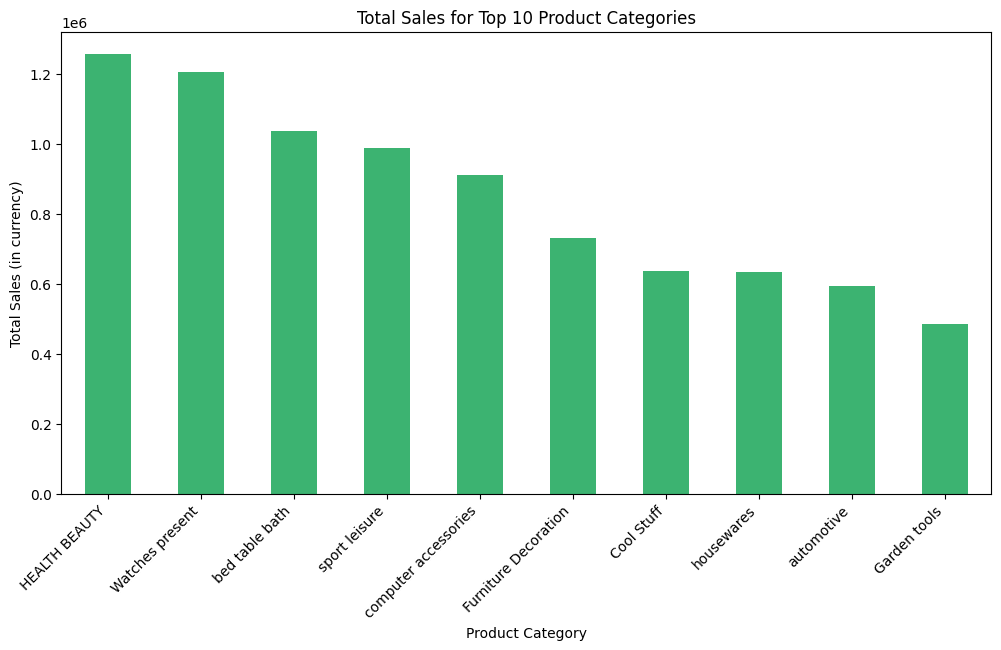

In [63]:
# Total Sales for Top 10 Categories

plt.figure(figsize=(12, 6))
sales_per_category.head(10).plot(kind='bar', color='mediumseagreen')
plt.title('Total Sales for Top 10 Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Total Sales (in currency)')
plt.xticks(rotation=45, ha='right')
plt.show()

### Calculate the percentage of orders that were paid in installments

In [64]:
# Count unique orders with more than 1 installment
installment_orders = payments[payments['payment_installments'] > 1]['order_id'].nunique()

# Count total unique orders in the payments dataset
total_orders = payments['order_id'].nunique()

percentage_installments = (installment_orders / total_orders) * 100
print(f"Percentage of orders paid in installments: {percentage_installments:.2f}%")

Percentage of orders paid in installments: 51.46%


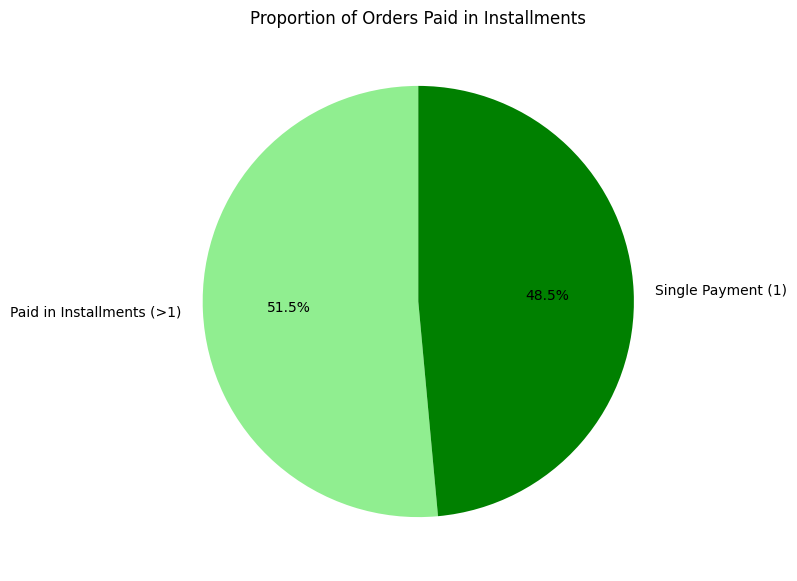

In [68]:
# Installments vs. Single Payment

plt.figure(figsize=(7, 7))
labels = ['Paid in Installments (>1)', 'Single Payment (1)']
sizes = [installment_orders, total_orders - installment_orders]
colors = ['lightgreen', 'green']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90,)
plt.title('Proportion of Orders Paid in Installments')
plt.show()

### Count the number of customers from each state

In [70]:
# Group by state and count unique customer IDs
customers_per_state = df.groupby('customer_state')['customer_unique_id'].nunique().sort_values(ascending=False)

print("Number of customers:")
print(customers_per_state)

Number of customers from top 5 states:
customer_state
SP    39972
RJ    12300
MG    11174
RS     5245
PR     4838
SC     3513
BA     3257
DF     2061
ES     1956
GO     1942
PE     1605
CE     1304
PA      944
MT      872
MA      718
MS      688
PB      516
PI      480
RN      471
AL      399
SE      338
TO      272
RO      235
AM      142
AC       77
AP       67
RR       45
Name: customer_unique_id, dtype: int64


### Calculate the number of orders per month in 2018

order_purchase_timestamp
1    7220
2    6694
3    7188
4    6934
5    6853
6    6160
7    6273
8    6452
9       1
Name: order_id, dtype: int64


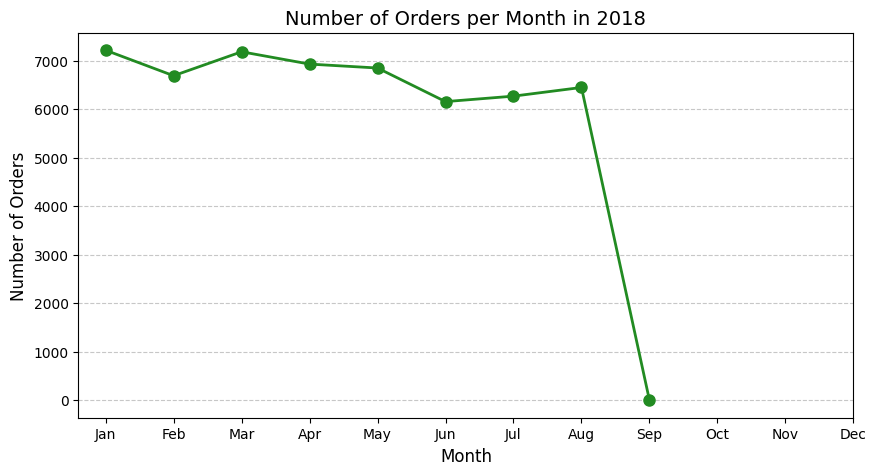

In [71]:
# Filter for 2018 and group by month to count unique orders
orders_2018 = df[df['order_purchase_timestamp'].dt.year == 2018]
monthly_orders_2018 = orders_2018.groupby(orders_2018['order_purchase_timestamp'].dt.month)['order_id'].nunique()

print(monthly_orders_2018)



In [ ]:
# Visualization
plt.figure(figsize=(10, 5))
monthly_orders_2018.plot(kind='line', marker='o', color='forestgreen', linewidth=2, markersize=8)
plt.title('Number of Orders per Month in 2018', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Find the average number of products per order, grouped by customer city

In [72]:
#count products per order per city
products_per_order = df.groupby(['order_id', 'customer_city'])['product_id'].count().reset_index()
products_per_order.rename(columns={'product_id': 'product_count'}, inplace=True)

# find the average product count per city
avg_products_city = products_per_order.groupby('customer_city')['product_count'].mean().sort_values(ascending=False)

print("Top 5 cities by average products per order:")
print(avg_products_city.head())

Top 5 cities by average products per order:
customer_city
padre carvalho    7.0
celso ramos       6.5
datas             6.0
candido godoi     6.0
matias olimpio    5.0
Name: product_count, dtype: float64


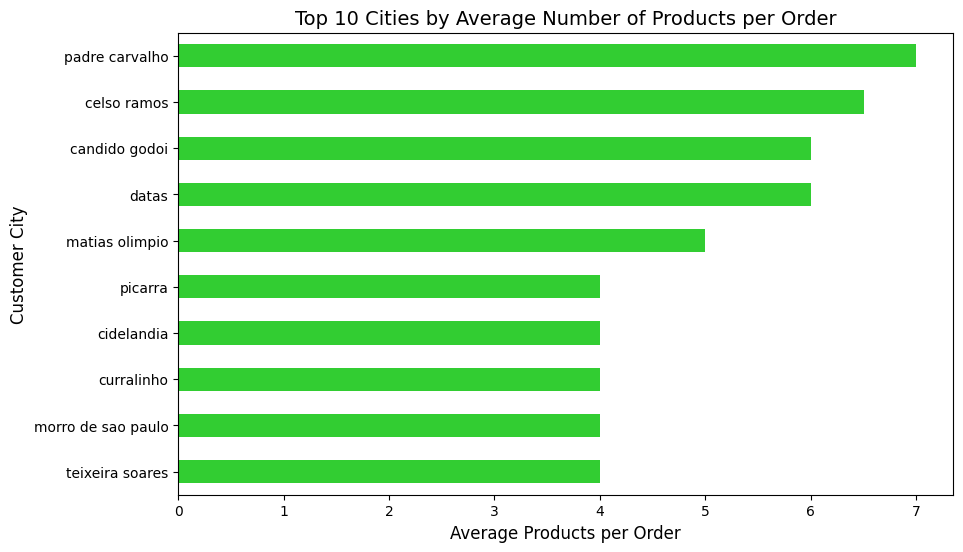

In [73]:
# Visualization (Top 10 Cities)
plt.figure(figsize=(10, 6))
avg_products_city.head(10).sort_values().plot(kind='barh', color='limegreen')
plt.title('Top 10 Cities by Average Number of Products per Order', fontsize=14)
plt.xlabel('Average Products per Order', fontsize=12)
plt.ylabel('Customer City', fontsize=12)
plt.show()

### Calculate the percentage of total revenue contributed by each product category

In [76]:
# Calculate revenue per category
revenue_by_cat = df.groupby('product category')['price'].sum().sort_values(ascending=False)

# Group top 5 and combine the rest into 'Others'
top_5_cat = revenue_by_cat.head(5)
others_cat = pd.Series({'Others': revenue_by_cat.iloc[5:].sum()})
combined_revenue = pd.concat([top_5_cat, others_cat])

# Calculate percentages for printing
total_revenue = combined_revenue.sum()
print((combined_revenue / total_revenue) * 100)

HEALTH BEAUTY            9.262639
Watches present          8.868591
bed table bath           7.631034
sport leisure            7.271327
computer accessories     6.711794
Others                  60.254615
dtype: float64


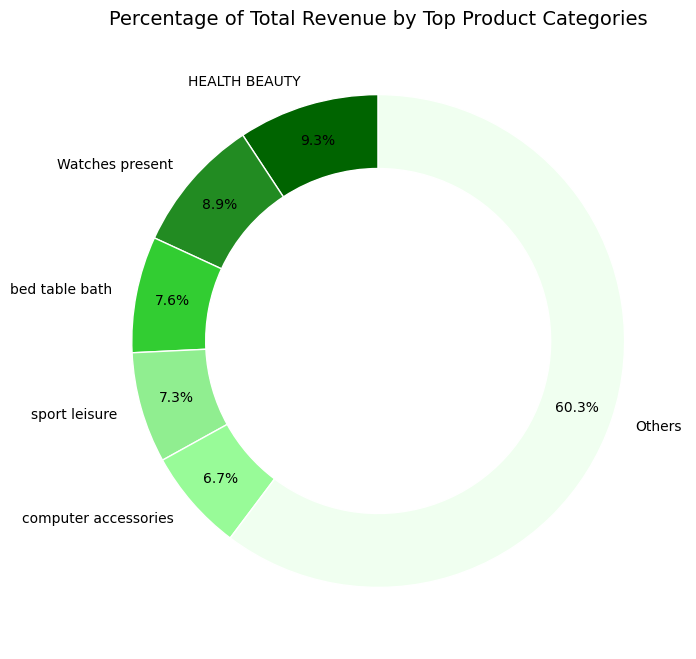

In [77]:
# Visualization
plt.figure(figsize=(8, 8))
colors = ['darkgreen', 'forestgreen', 'limegreen', 'lightgreen', 'palegreen', 'honeydew']

plt.pie(combined_revenue, labels=combined_revenue.index, autopct='%1.1f%%',
        colors=colors, startangle=90, pctdistance=0.85, wedgeprops=dict(width=0.3, edgecolor='w'))

# Add a circle at the center to make it a donut chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Percentage of Total Revenue by Top Product Categories', fontsize=14)
plt.show()

### Identify the correlation between product price and the number of times a product has been purchased

In [78]:
# Group by product_id to get total purchases and average price
product_stats = df.groupby('product_id').agg(
    total_purchases=('order_id', 'count'),
    avg_price=('price', 'mean')
).reset_index()

# Calculate correlation coefficient
correlation = product_stats['avg_price'].corr(product_stats['total_purchases'])
print(f"Correlation between price and times purchased: {correlation:.4f}")

Correlation between price and times purchased: -0.0321


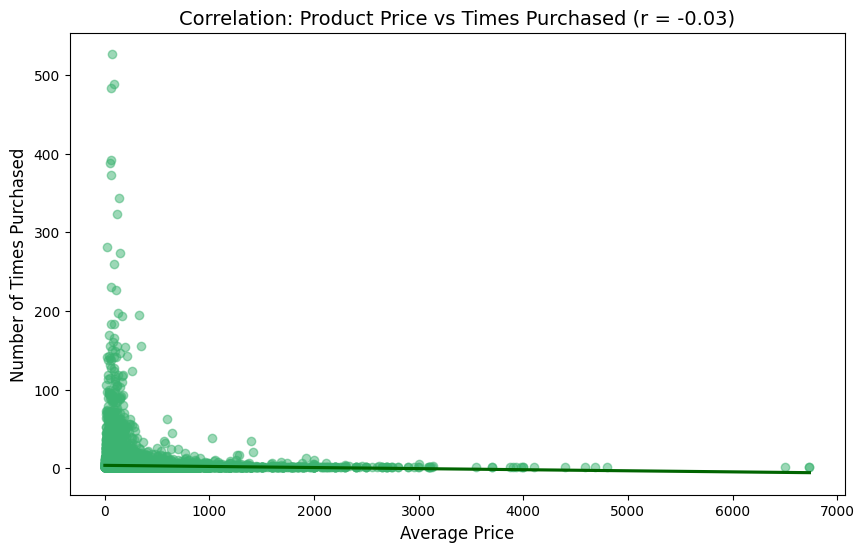

In [79]:
# Visualization
plt.figure(figsize=(10, 6))
sns.regplot(data=product_stats, x='avg_price', y='total_purchases',
            scatter_kws={'color': 'mediumseagreen', 'alpha': 0.5},
            line_kws={'color': 'darkgreen'})

plt.title(f'Correlation: Product Price vs Times Purchased (r = {correlation:.2f})', fontsize=14)
plt.xlabel('Average Price', fontsize=12)
plt.ylabel('Number of Times Purchased', fontsize=12)
plt.show()

### Calculate the total revenue generated by each seller, and rank them by revenue

In [80]:
# Group by seller_id and sum the price to get total revenue
seller_revenue = df.groupby('seller_id')['price'].sum().sort_values(ascending=False)

print("Top 5 Sellers by Revenue:")
print(seller_revenue.head())

Top 5 Sellers by Revenue:
seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
Name: price, dtype: float64


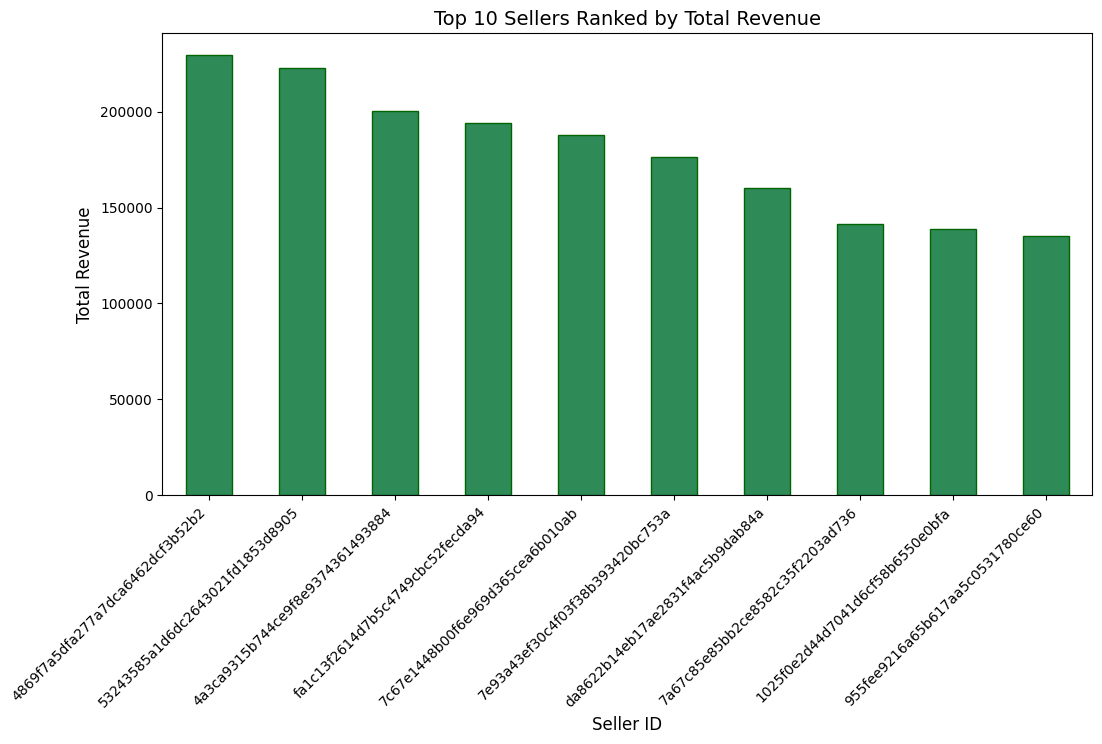

In [85]:
# Visualization (Top 10 Sellers)
plt.figure(figsize=(12, 6))
seller_revenue.head(10).plot(kind='bar', color='seagreen', edgecolor='darkgreen')
plt.title('Top 10 Sellers Ranked by Total Revenue', fontsize=14)
plt.xlabel('Seller ID', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

### Calculate the moving average of order values for each customer

In [86]:
# Convert to datetime and sort by customer and purchase date
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df_sorted = df.sort_values(by=['customer_unique_id', 'order_purchase_timestamp'])

# Calculate the expanding (moving) average of the price per customer
df_sorted['moving_avg_order_value'] = df_sorted.groupby('customer_unique_id')['price'].transform(lambda x: x.expanding().mean())

# Identify the top 3 most frequent customers for visualization
top_customers = df_sorted['customer_unique_id'].value_counts().head(3).index

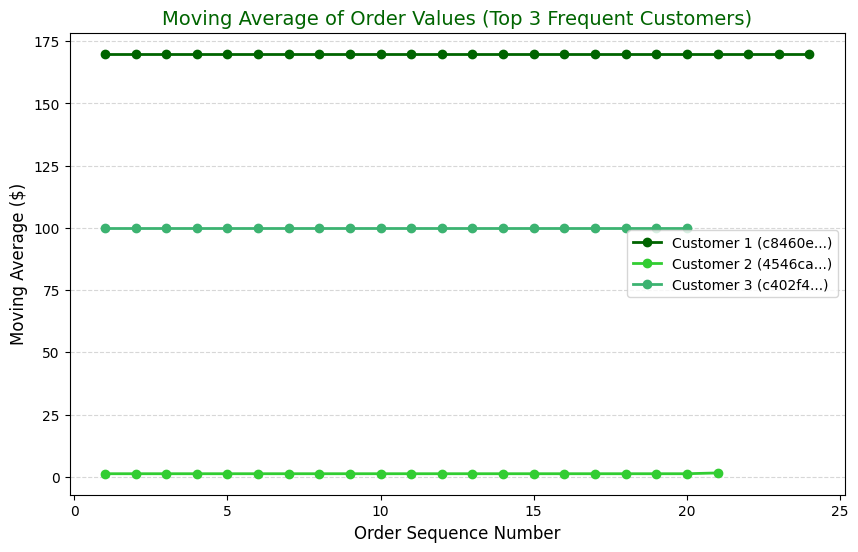

In [87]:
# Visualization
plt.figure(figsize=(10, 6))
colors = ['darkgreen', 'limegreen', 'mediumseagreen']

for i, cust_id in enumerate(top_customers):
    cust_data = df_sorted[df_sorted['customer_unique_id'] == cust_id].reset_index()
    plt.plot(cust_data.index + 1, cust_data['moving_avg_order_value'],
             marker='o', linestyle='-', linewidth=2, color=colors[i],
             label=f'Customer {i+1} ({cust_id[:6]}...)')

plt.title('Moving Average of Order Values (Top 3 Frequent Customers)', fontsize=14, color='darkgreen')
plt.xlabel('Order Sequence Number', fontsize=12)
plt.ylabel('Moving Average ($)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Calculate the cumulative sales per month for each year

In [88]:
# Extract year and month
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month

# Calculate total sales per month per year
monthly_sales = df.groupby(['year', 'month'])['price'].sum().reset_index()

# Calculate cumulative sum within each year
monthly_sales['cumulative_sales'] = monthly_sales.groupby('year')['price'].cumsum()

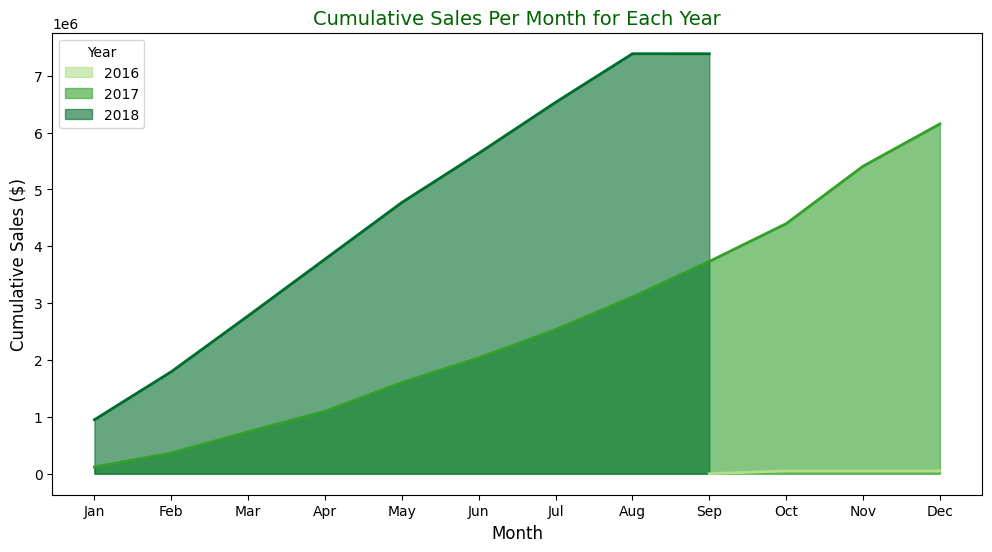

In [89]:
# Visualization
plt.figure(figsize=(12, 6))
years = monthly_sales['year'].unique()
green_shades = ['#b2df8a', '#33a02c', '#006d2c'] # Light to dark green

for i, year in enumerate(years):
    year_data = monthly_sales[monthly_sales['year'] == year]
    plt.fill_between(year_data['month'], year_data['cumulative_sales'],
                     color=green_shades[i % len(green_shades)], alpha=0.6, label=str(year))
    plt.plot(year_data['month'], year_data['cumulative_sales'],
             color=green_shades[i % len(green_shades)], linewidth=2)

plt.title('Cumulative Sales Per Month for Each Year', fontsize=14, color='darkgreen')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Cumulative Sales ($)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year')
plt.show()

### Calculate the year-over-year (YoY) growth rate of total sales

In [90]:
# Calculate total sales per year
yearly_sales = df.groupby('year')['price'].sum().reset_index()

# Calculate YoY percentage change
yearly_sales['yoy_growth'] = yearly_sales['price'].pct_change() * 100

print(yearly_sales[['year', 'yoy_growth']].dropna())

   year    yoy_growth
1  2017  12289.772099
2  2018     20.066378


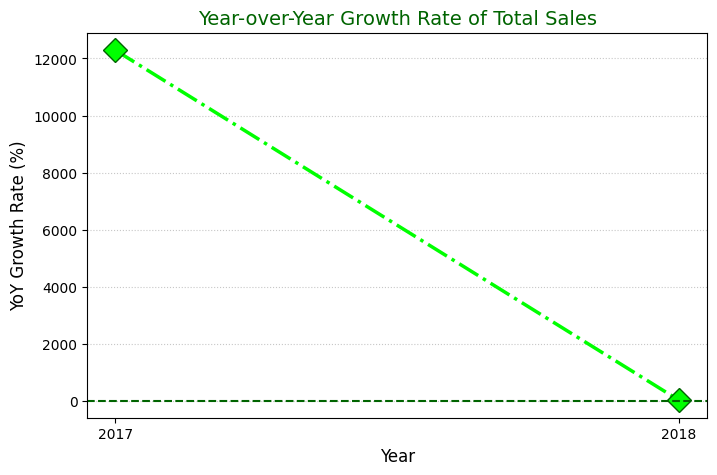

In [91]:
# Visualization
plt.figure(figsize=(8, 5))
plt.plot(yearly_sales['year'].astype(str), yearly_sales['yoy_growth'],
         marker='D', markersize=12, color='lime', linestyle='-.', linewidth=2.5, markeredgecolor='darkgreen')

plt.axhline(0, color='darkgreen', linewidth=1.5, linestyle='--') # 0% growth baseline
plt.title('Year-over-Year Growth Rate of Total Sales', fontsize=14, color='darkgreen')
plt.xlabel('Year', fontsize=12)
plt.ylabel('YoY Growth Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

### Calculate the retention rate of customers (repurchase within 6 months)

In [92]:
# Find the first purchase date for each customer
first_purchases = df.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_purchases.columns = ['customer_unique_id', 'first_purchase_date']

# Merge back and calculate time difference in days
merged = pd.merge(df, first_purchases, on='customer_unique_id')
merged['days_since_first'] = (merged['order_purchase_timestamp'] - merged['first_purchase_date']).dt.days

# A customer is retained if they made a purchase between 1 and 180 days (approx 6 months) later
retained = merged[(merged['days_since_first'] > 0) & (merged['days_since_first'] <= 180)]['customer_unique_id'].nunique()
total_customers = first_purchases['customer_unique_id'].nunique()

retention_rate = (retained / total_customers) * 100
print(f"6-Month Retention Rate: {retention_rate:.2f}%")

6-Month Retention Rate: 1.63%


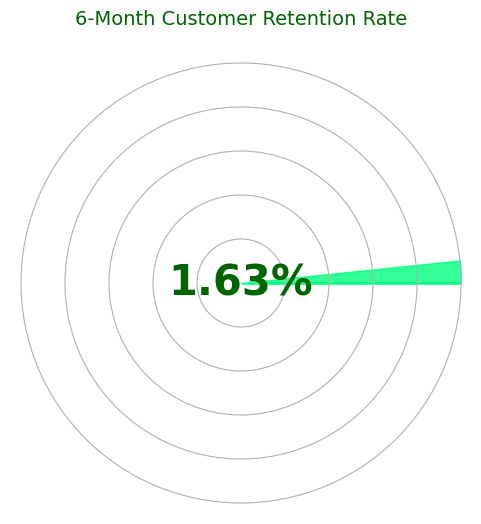

In [93]:
# Visualization (Polar Gauge)
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)

# Create the filled gauge representing the percentage
theta = np.linspace(0, 2 * np.pi * (retention_rate / 100), 100)
r = np.ones(100)
ax.fill_between(theta, 0, r, color='springgreen', alpha=0.8)

ax.set_yticklabels([]) # Hide radial ticks
ax.set_xticks([])      # Hide angular ticks
ax.spines['polar'].set_visible(False)

plt.text(0, 0, f'{retention_rate:.2f}%', ha='center', va='center', fontsize=30, color='darkgreen', weight='bold')
plt.title('6-Month Customer Retention Rate', color='darkgreen', fontsize=14, pad=20)
plt.show()

### Identify the top 3 customers who spent the most money in each year

In [94]:
# Calculate total spent per customer per year
yearly_cust_sales = df.groupby(['year', 'customer_unique_id'])['price'].sum().reset_index()

# Rank and get the top 3 for each year
top_3_per_year = yearly_cust_sales.sort_values(['year', 'price'], ascending=[True, False]).groupby('year').head(3)

print("Top 3 Spenders per Year:")
print(top_3_per_year)

Top 3 Spenders per Year:
       year                customer_unique_id     price
302    2016  fdaa290acb9eeacb66fa7f979baa6803   1399.00
136    2016  753bc5d6efa9e49a03e34cf521a9e124   1299.99
220    2016  b92a2e5e8a6eabcc80882c7d68b2c70b   1199.00
2040   2017  0a0a92112bd4c708ca5fde585afaa872  13440.00
37207  2017  da122df9eeddfedc1dc1f5349a1a690c   7388.00
37577  2017  dc4802a71eae9be1dd28f5d788ceb526   6735.00
67843  2018  763c8b1c9c68a0229c42c9fc6f662b93   7160.00
57825  2018  459bef486812aa25204be022145caa62   6729.00
62672  2018  5d0a2980b292d049061542014e8960bf   4599.90


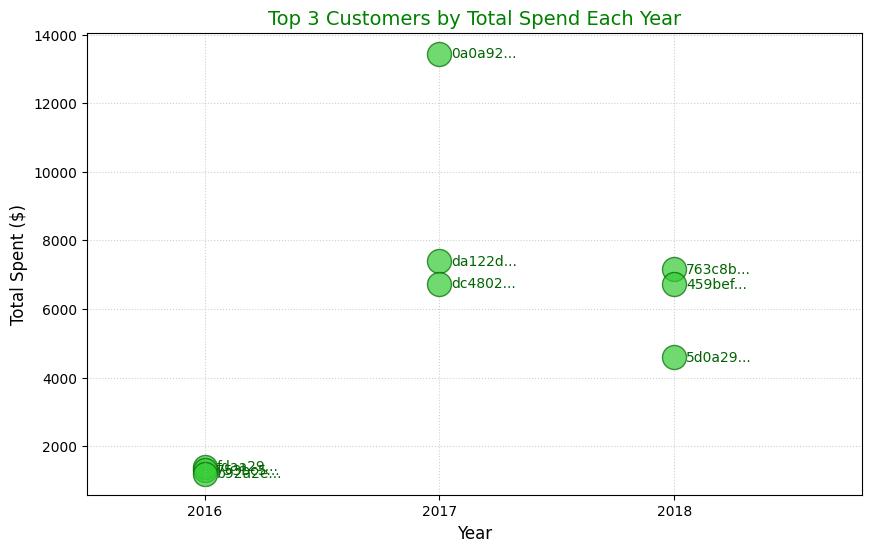

In [99]:
# Visualization
plt.figure(figsize=(10, 6))
years = top_3_per_year['year'].unique()

for year in years:
    year_data = top_3_per_year[top_3_per_year['year'] == year]
    # Plot as a scatter point
    plt.scatter([year] * len(year_data), year_data['price'], s=300, color='limegreen', alpha=0.7, edgecolors='darkgreen')

    # Annotate each point with the customer's ID snippet
    for _, row in year_data.iterrows():
        plt.annotate(row['customer_unique_id'][:6] + '...',
                     (year + 0.05, row['price']),
                     fontsize=10, color='darkgreen', va='center')

plt.title('Top 3 Customers by Total Spend Each Year', fontsize=14, color='green')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Spent ($)', fontsize=12)
plt.xticks(years)
plt.grid(True, linestyle=':', alpha=0.6)
# Increase x-axis limit slightly so text doesn't cut off
plt.xlim(years.min() - 0.5, years.max() + 0.8)
plt.show()

## Conclusion

This Exploratory Data Analysis provides a comprehensive overview of the sales ecosystem, revealing key patterns in customer behavior, product performance, and revenue generation. By diving into the historical order data, we successfully identified seasonal trends and calculated critical business metrics, including year-over-year growth and customer retention rates. The geographical distribution of our user base highlights our strongest markets, while tracking the moving average of order values offers a clear window into long-term purchasing habits.

Furthermore, exploring the correlation between product price and purchase frequency provides actionable insights for future pricing strategies. Moving forward, these foundational discoveries will serve as a springboard for more advanced analytics. The insights and transformed variables gathered here are primed for robust feature engineering, which will be essential for building predictive machine learning models to forecast future sales, anticipate customer churn, and optimize overall inventory management.